# 02 — Sentiment engine & acquisition scorecard

1. **Review-level sentiment engine** — trained on labelled Steam reviews so unlabelled review text from any source can be scored at scale.
2. **Game-level scorecard** — with only 23 titles a game-level ML model is indefensible; titles are ranked by a transparent weighted index instead.


In [1]:
import pickle
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

RANDOM_STATE = 42

df = pd.read_csv('../outputs/df_clean.csv', parse_dates=['date_posted'])
df = df.dropna(subset=['review'])    # Drop 7 missing values (this is neglegable)

counts = df['title'].value_counts()
df['thin_coverage'] = df['title'].map(counts) < 100
print(df.shape, '| thin-coverage titles:', df.loc[df['thin_coverage'], 'title'].nunique())

(14610, 9) | thin-coverage titles: 5


## Leakage audit — what exists at the prediction moment?

The engine scores a review the instant it appears.

| Column | Ruling |
|---|---|
| `review` | **Feature** — core input |
| `hour_played` | **Feature** — hours played *before* writing, known at posting |
| `is_early_access_review` | **Feature** — known at posting |
| `funny`, `helpful` | **Excluded** — votes accumulate *after* posting; zero on a fresh review |
| `title` | **Excluded** — the engine must generalise to games it has never seen |
| `date_posted` | Scorecard trend features only |
| `recommendation` | Target |



In [2]:
FEATURES = ['review', 'hour_played', 'is_early_access_review']
X = df[FEATURES]
y = (df['recommendation'] == 'Recommended').astype(int)

from sklearn.model_selection import train_test_split
X_tr, X_te, y_tr, y_te = train_test_split(X, y, test_size=0.2, stratify=y,
                                          random_state=RANDOM_STATE)

**Used Stratified train test split to ensure balanced partitioning of classes**

## Model — TF-IDF text (uni+bigrams) + playtime + early-access flag, Logistic Regression
Playtime is log-scaled (heavy right skew) then standardised so its coefficient is comparable to the word weights. `class_weight='balanced'` for the 71/29 imbalance; metrics are per-class precision/recall and PR-AUC on the minority class not accuracy since unbalanced data.


In [3]:
from sklearn.pipeline import make_pipeline
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, FunctionTransformer
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, average_precision_score

hours_pipe = make_pipeline(
    FunctionTransformer(np.log1p, feature_names_out='one-to-one'),
    StandardScaler(),
)

pre = ColumnTransformer([
    ('text',  TfidfVectorizer(stop_words='english', min_df=5, ngram_range=(1, 2)), 'review'),
    ('hours', hours_pipe,    ['hour_played']),
    ('ea',    'passthrough', ['is_early_access_review']),
])

model = Pipeline([
    ('pre', pre),
    ('clf', LogisticRegression(max_iter=1000, class_weight='balanced',
                               random_state=RANDOM_STATE)),
])
model.fit(X_tr, y_tr)

proba = model.predict_proba(X_te)[:, 1]
print(classification_report(y_te, (proba >= 0.5).astype(int),
                            target_names=['Not Recommended', 'Recommended'], digits=3))


                 precision    recall  f1-score   support

Not Recommended      0.685     0.810     0.742       844
    Recommended      0.917     0.848     0.881      2078

       accuracy                          0.837      2922
      macro avg      0.801     0.829     0.812      2922
   weighted avg      0.850     0.837     0.841      2922



**Another impartant class imbalance handling is the class_weight='balanced' so that the mistakes on the 29% minority class cost proportionally more during training**

**Takeaway:** model recovers 81% of negative reviews at 0.685 precision, while scoring positives precision at 0.917. PR-AUC on the minority Not Recommended class is 0.827 against a 0.29 baseline


## Does it generalise to games it has never seen?
GroupKFold by title — every fold tests on games absent from training. This is the deployment scenario: scoring reviews of *candidate* games outside the catalogue.

In [4]:
from sklearn.model_selection import GroupKFold
from sklearn.base import clone

scores = []
for tr_idx, te_idx in GroupKFold(n_splits=5).split(X, y, groups=df['title']):
    m = clone(model).fit(X.iloc[tr_idx], y.iloc[tr_idx])
    p = m.predict_proba(X.iloc[te_idx])[:, 1]
    scores.append(average_precision_score(1 - y.iloc[te_idx], 1 - p))
print('PR-AUC per unseen-game fold:', [round(s, 3) for s in scores])
print(f'Mean: {np.mean(scores):.3f} +/- {np.std(scores):.3f}')

PR-AUC per unseen-game fold: [0.762, 0.71, 0.682, 0.839, 0.756]
Mean: 0.750 +/- 0.053


**Takeaway:** _fill in — the unseen-game mean is the number GameVault should plan around._

## What drives the score - AI used here


Structured features: {'hours__hour_played': 0.356, 'ea__is_early_access_review': 0.529}


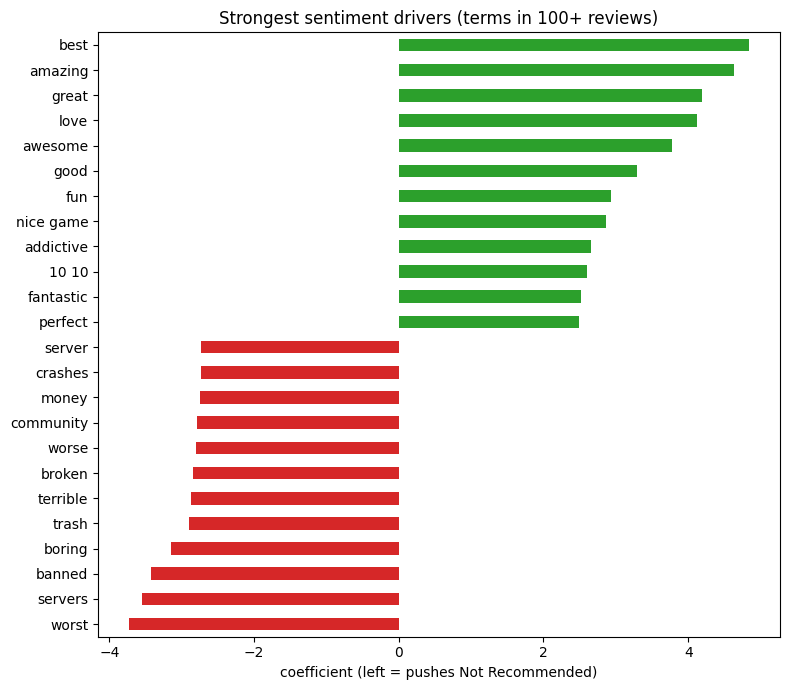

In [5]:
names = model.named_steps['pre'].get_feature_names_out()
coef = pd.Series(model.named_steps['clf'].coef_[0], index=names)
print('Structured features:', coef[~coef.index.str.startswith('text__')].round(3).to_dict())

vec = model.named_steps['pre'].named_transformers_['text']
doc_freq = pd.Series(np.asarray((vec.transform(X_tr['review']) > 0).sum(axis=0)).ravel(),
                     index=['text__' + n for n in vec.get_feature_names_out()])
text_coef = coef[coef.index.str.startswith('text__')]
common = text_coef[doc_freq[text_coef.index] >= 100]   # systematic drivers, not rare-term noise

top = pd.concat([common.nsmallest(12), common.nlargest(12).sort_values()])
top.index = top.index.str.replace('text__', '', regex=False)
fig, ax = plt.subplots(figsize=(8, 7))
top.plot(kind='barh', ax=ax, color=np.where(top < 0, '#d62728', '#2ca02c'))
ax.set_xlabel('coefficient (left = pushes Not Recommended)')
ax.set_title('Strongest sentiment drivers (terms in 100+ reviews)')
plt.tight_layout()
plt.savefig('../outputs/feature_importance.png', dpi=150)
plt.show()

## Score every review honestly, then save the deployment model
Out-of-fold predictions give each review a score from a model that never trained on it; the saved artifact is refitted on all data.


In [6]:
from sklearn.model_selection import StratifiedKFold, cross_val_predict
from sklearn.base import clone

skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)
df['sentiment'] = cross_val_predict(model, X, y, cv=skf, method='predict_proba')[:, 1]

final_model = clone(model).fit(X, y)
with open('../outputs/sentiment_model.pkl', 'wb') as f:
    pickle.dump(final_model, f)
print('saved ../outputs/sentiment_model.pkl')

saved ../outputs/sentiment_model.pkl


## Acquisition scorecard

| Component | Built from | Weight |
|---|---|---|
| Sentiment health | % recommended (lifetime) | 0.40 |
| Momentum | last-6-months % − lifetime % | 0.30 |
| Regular player | median hours played (log) | 0.30 |

Components are the analysis; weights are strategy — adjustable live in the dashboard.

In [10]:
rows = []
for t, g in df.groupby('title'):
    recent = g[g['date_posted'] > g['date_posted'].max() - pd.Timedelta(days=180)]
    rows.append({
        'title': t,
        'n_reviews': len(g),
        'thin_coverage': bool(g['thin_coverage'].iloc[0]),
        'pct_recommended': (g['recommendation'] == 'Recommended').mean(),
        'mean_sentiment': g['sentiment'].mean(),
        'recent_6m_pct': (recent['recommendation'] == 'Recommended').mean(),
        'median_hours': g['hour_played'].median(),
        'ea_share': g['is_early_access_review'].mean(),
        'last_review': g['date_posted'].max().date(),
    })
scorecard = pd.DataFrame(rows)
scorecard['momentum'] = scorecard['recent_6m_pct'] - scorecard['pct_recommended']


def norm(col, transform=None):
    v = scorecard[col].astype(float)
    if transform is not None:
        v = transform(v)
    ref = v[~scorecard['thin_coverage']]   # scale anchored on adequately-covered titles
    return ((v - ref.min()) / (ref.max() - ref.min())).clip(0, 1)


scorecard['score_sentiment'] = norm('pct_recommended')
scorecard['score_momentum'] = norm('momentum')
scorecard['score_regular'] = norm('median_hours', np.log1p)

WEIGHTS = {'score_sentiment': 0.40, 'score_momentum': 0.30, 'score_regular': 0.30}
scorecard['composite'] = sum(scorecard[c] * w for c, w in WEIGHTS.items()) * 100
scorecard = scorecard.sort_values('composite', ascending=False).reset_index(drop=True)
scorecard.round(3)

,title,n_reviews,thin_coverage,pct_recommended,mean_sentiment,recent_6m_pct,median_hours,ea_share,last_review,momentum,score_sentiment,score_momentum,score_regular,composite
0,Terraria,239,False,1.000,0.783,1.000,283.0,0.000,2018-12-24,0.000,1.000,0.389,1.000,81.676
1,Factorio,158,False,1.000,0.697,1.000,176.5,1.000,2018-10-01,0.000,1.000,0.389,0.816,76.164
2,RimWorld,184,False,1.000,0.742,1.000,130.5,0.940,2019-01-11,0.000,1.000,0.389,0.699,72.646
3,Slay the Spire,231,False,0.991,0.790,0.995,107.0,0.991,2019-01-23,0.004,0.978,0.407,0.622,69.998
4,Euro Truck Simulator 2,330,False,1.000,0.807,1.000,96.0,0.000,2017-07-25,0.000,1.000,0.389,0.580,69.077
5,Stardew Valley,183,False,1.000,0.800,1.000,91.0,0.000,2019-01-15,0.000,1.000,0.389,0.559,68.456
6,Left 4 Dead 2,202,False,0.995,0.750,1.000,82.5,0.000,2019-01-17,0.005,0.988,0.411,0.521,67.476
7,Subnautica,204,False,1.000,0.803,1.000,60.0,0.201,2019-01-14,0.000,1.000,0.389,0.399,63.637
8,Grand Theft Auto V,2173,False,0.632,0.533,0.771,182.0,0.000,2019-02-16,0.139,0.079,1.000,0.828,58.005
9,Beat Saber,10,True,1.000,0.678,1.000,26.5,1.000,2018-12-24,0.000,1.000,0.389,0.087,54.293


**Takeaway:** top 3 games are Terraria, factorio, RimWorld


In [12]:
export = df[['title', 'date_posted', 'recommendation', 'sentiment', 'hour_played',
             'is_early_access_review', 'helpful', 'funny', 'thin_coverage']].copy()
export['review_snippet'] = df['review'].str.slice(0, 240)   # snippets only - raw dataset stays out of the public repo
export.sort_values('date_posted').to_csv('../outputs/scored_records.csv', index=False)
scorecard.to_csv('../outputs/game_scorecard.csv', index=False)
print('saved scored_records.csv', export.shape, '| game_scorecard.csv', scorecard.shape)

saved scored_records.csv (14610, 10) | game_scorecard.csv (23, 14)
